# METS-R SIM: interactive usage tutorial

This notebook walks through the four main ways a Python client talks to a running METS-R simulator:

1. **Simulation lifecycle** &mdash; configure, launch, reset, reconnect, and terminate a simulation container.
2. **Query APIs** &mdash; read the state of vehicles, roads, signals, and facilities.
3. **Control APIs** &mdash; inject trips, dispatch taxis, adjust bus schedules, teleport vehicles, and drive traffic signals.
4. **Real-time data stream** &mdash; consume the Kafka feed emitted by the simulator for V2X / sensing experiments.

Every section is self-contained: each one (re)starts its own simulator and tears it down at the end, so you can jump straight to the section you care about.

## Setup

This notebook lives under `tutorials/`, but the helper modules (`utils`, `clients`) and the `configs/`, `data/`, and `docker/` folders all sit at the repo root. The cell below switches the working directory to the repo root and makes those packages importable, so the rest of the notebook can keep using short relative paths such as `configs/run_cosim_CARLAT5.json`.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "tutorials":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())


# Section 1: Simulation lifecycle

Every METS-R experiment follows the same skeleton:

1. Read a run configuration JSON.
2. Prepare per-run output directories and launch the Java simulator inside a Docker container.
3. Connect a `METSRClient` over a WebSocket.
4. Advance the clock with `tick()`, interleaving queries and control calls.
5. Optionally `reset()` the world.
6. `terminate()` the simulator when done.

This section uses the CARLA Town05 co-simulation config purely as a small, self-contained map &mdash; the lifecycle commands are the same for every scenario.

## 1.1 Start a simulation

In [2]:
from utils.util import *
from clients.METSRClient import METSRClient

Load a run config. Setting `verbose=True` makes the client echo every WebSocket message, which is handy while you're learning the API.

In [3]:
config = read_run_config("configs/run_cosim_CARLAT5.json")

`prepare_sim_dirs` copies the data files referenced in the config into a timestamped output folder and returns the per-instance paths. `run_simulation_in_docker` then launches one container per instance.

In [4]:
sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)

['output/CARLAT05_20260531_235831_seed_42']


Connect the Python client to the simulator running in the container on port 4000. The constructor blocks until the handshake succeeds.

In [5]:
client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port=4000)

Connection established!


(Optional) Start the lightweight HTTP server that serves the per-tick trajectory files so you can replay them in the [METS-R Vis](https://engineering.purdue.edu/HSEES/METSRVis/) browser front-end.

In [6]:
# start the visualization server so the trajectory can be visualized at https://engineering.purdue.edu/HSEES/METSRVis/
client.start_viz()

Starting visualization server for metsr-trajectory-binary v7 sparse trajectory output: output/CARLAT05_20260531_235831_seed_42\trajectory_output\2026-05-31-2258-40
Serving output/CARLAT05_20260531_235831_seed_42\trajectory_output\2026-05-31-2258-40 with CORS enabled on port 8000...


127.0.0.1 - - [31/May/2026 23:59:04] "GET / HTTP/1.1" 200 -
----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 64060)
Traceback (most recent call last):
  File "c:\Users\ALei\anaconda3\envs\carla2\lib\socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "c:\Users\ALei\anaconda3\envs\carla2\lib\socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "c:\Users\ALei\anaconda3\envs\carla2\lib\socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "c:\Users\ALei\Documents\GitHub\METS-R_HPC\utils\util.py", line 470, in <lambda>
    handler_class = lambda *args, **kwargs: CORSRequestHandler(*args, directory=directory, **kwargs)
  File "c:\Users\ALei\Documents\GitHub\METS-R_HPC\utils\util.py", line 456, in __init__
    super().__init__(*args, directory=directory, **kwargs)
  F

## 1.2 Advance the clock

`client.tick(N)` asks the server to step `N` ticks (0.1 s each in this config) and blocks until the server acknowledges. You can issue queries or commands between ticks.

In [7]:
client.tick(1000)

### Generating trips

Passing `-1` as origin / destination asks the simulator to sample them uniformly. This loop injects 50 private-vehicle trips, spaced 10 ticks apart, while advancing the clock.

In [8]:
# Generating 50 trips in 500 ticks.
for i in range(500):
      if(i % 10 == 0):
            client.generate_trip(i, -1, -1)
      client.tick(1)

## 1.3 Reset the world

`reset()` rolls the simulator back to `tick 0` **without** relaunching the container. All vehicles, demand, and facility state are cleared.

In [9]:
# reset the simulation using CARLA Town05's map
client.reset()

Visualization server stopped.
Starting visualization server for metsr-trajectory-binary v7 sparse trajectory output: output/CARLAT05_20260531_235831_seed_42\trajectory_output\2026-05-31-2259-03
Serving output/CARLAT05_20260531_235831_seed_42\trajectory_output\2026-05-31-2259-03 with CORS enabled on port 8000...


127.0.0.1 - - [31/May/2026 23:59:39] "GET / HTTP/1.1" 200 -
----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 63839)
Traceback (most recent call last):
  File "c:\Users\ALei\anaconda3\envs\carla2\lib\socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "c:\Users\ALei\anaconda3\envs\carla2\lib\socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "c:\Users\ALei\anaconda3\envs\carla2\lib\socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "c:\Users\ALei\Documents\GitHub\METS-R_HPC\utils\util.py", line 470, in <lambda>
    handler_class = lambda *args, **kwargs: CORSRequestHandler(*args, directory=directory, **kwargs)
  File "c:\Users\ALei\Documents\GitHub\METS-R_HPC\utils\util.py", line 456, in __init__
    super().__init__(*args, directory=directory, **kwargs)
  F

Same 50 trips as before, but issued in one batch after each 10-tick window &mdash; significantly fewer round-trips.

In [10]:
# This is doing the same thing as above, but in a more efficient way
for i in range(50):
      client.generate_trip(i, -1, -1)
      client.tick(10)

## 1.4 Trips between specific roads

`query_road()` with no argument returns every road ID known to the simulator. `generate_trip_between_roads` then lets you dictate the O-D pair rather than sampling it.

In [11]:
# generate trips between roads
import random
road_ids = client.query_road()
road_ids

{'id_list': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80],
 'orig_id': ['-0',
  '-1',
  '-10',
  '-11',
  '-13',
  '-14',
  '-16',
  '-18',
  '-19',
  '-2',
  '-20',
  '-21',
  '-22',
  '-23',
  '-24',
  '-26',
  '-27',
  '-28',
  '-29',
  '-3',
  '-30',
  '-32',
  '-36',
  '-38',
  '-39',
  '-4',
  '-41',
  '-42',
  '-43',
  '-44',
  '-45',
  '-46',
  '-47',
  '-48',
  '-5',
  '-50',
  '-51',
  '-52',
  '-6',
  '-7',
  '-8',
  '-9',
  '0',
  '1',
  '10',
  '11',
  '13',
  '15',
  '17',
  '19',
  '2',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '27',
  '28',
  '3'

In [12]:
for i in range(500):
      client.tick(10)
      origin_road = random.choice(road_ids['orig_id'])
      destination_road = random.choice(road_ids['orig_id'])
      client.generate_trip_between_roads(i, origin_road, destination_road)

## 1.5 Clean up

In [13]:
# stop the visualization server, note visualization server is already stopped when the previous client is closed so nothing is going to be printed
client.stop_viz()

Visualization server stopped.


In [15]:
# terminate the simulation, note if the visualization server is not stopped, it will be automatically stopped when the simulation is terminated, so most of time you don't need to stop the visualization server like above
client.terminate()

# Section 2: Query APIs

Query calls are read-only: they pull state out of the simulator without changing it. We switch to the NYC interactive scenario because it has a full bus schedule, e-taxi fleet, and realistic ride-hail demand &mdash; plenty for the queries to return meaningful data.

## 2.1 Launch the NYC scenario

In [38]:
from utils.util import *
from clients.METSRClient import METSRClient

In [39]:
config = read_run_config("configs/run_interactive_NYC.json")

In [40]:
sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)

No port number specified, find available ports for simulation instances
['output/NYC_20260601_000659_seed_42']


When `metsr_port` is omitted from the config, `prepare_sim_dirs` picks free ports automatically and stores them on the config object.

In [41]:
# If no metsr_port is specified, the runner will find the port automatically 
config.ports

[53179]

Bigger scenarios need a larger request timeout. 300 s is generous for NYC; raise it further if you see timeout errors.

In [42]:
# Better to  set up a larger timeout (default is 30s) if your map/vehicle number is huge
sim_client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port = config.ports[0], timeout=300) 

Connection established!


Warm the simulation up for 10 minutes of simulated time (3 000 ticks at 0.2 s / tick). `wait_forever=True` prevents timeouts on very long ticks.

In [43]:
sim_client.tick(3000, wait_forever=True)

The above approach may be less transparent when running a large number of ticks. A more reactive way to run the simulation is as follows.|

In [44]:
from tqdm import tqdm

for i in tqdm(range(10)):
      sim_client.tick(300, wait_forever=True)

100%|██████████| 10/10 [00:02<00:00,  4.43it/s]


## 2.2 Vehicle queries

`query_bus` / `query_taxi` with no argument return the list of IDs in that fleet. Pass an ID to get the full state object for that vehicle.

In [45]:
# if no vehicle id is specified, a list of all buses will be returned
sim_client.query_bus()

{'id_list': [4032,
  4033,
  4034,
  4035,
  4036,
  4037,
  4038,
  4039,
  4000,
  4001,
  4002,
  4003,
  4004,
  4005,
  4006,
  4007,
  4008,
  4009,
  4010,
  4011,
  4012,
  4013,
  4014,
  4015,
  4016,
  4017,
  4018,
  4019,
  4020,
  4021,
  4022,
  4023,
  4024,
  4025,
  4026,
  4027,
  4028,
  4029,
  4030,
  4031],
 'TYPE': 'ANS_bus'}

Single bus &mdash; note the `current_stop` field telling us this vehicle has already reached its second stop.

In [46]:
# this vehicle has reached the second stop
sim_client.query_bus(4032)

{'DATA': [{'matchedPassengers': 0,
   'battery_state': 229.31127184638288,
   'pickupPassengers': 0,
   'route': '1640002',
   'stopZones': [181, 157, 228, 176, 181],
   'current_stop': 1,
   'pass_num': 0,
   'matchedRequests': 0,
   'dropoffPassengers': 0,
   'dropoffRequests': 0,
   'pickupRequests': 0,
   'ID': 4032}],
 'TYPE': 'ANS_bus'}

In [47]:
# similarly, one can query taxis
sim_client.query_taxi()

{'id_list': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,


`state == 0` means the taxi is parked and waiting for a request.

In [48]:
# This vehicle is in state 0, meaning it is parking
sim_client.query_taxi(0)

{'DATA': [{'matchedPassengers': 1,
   'pass_num': 1,
   'matchedRequests': 1,
   'onBoardReqIDs': [1],
   'origin': 132,
   'dropoffPassengers': 0,
   'dest': 124,
   'toBoardReqIDs': [],
   'pickupPassengers': 1,
   'x': -73.80437042785395,
   'dropoffRequests': 0,
   'y': 40.68019705214965,
   'z': 0.0,
   'pickupRequests': 1,
   'ID': 0,
   'state': 1}],
 'TYPE': 'ANS_taxi'}

In [ ]:
# the definition of the state can be found using
?sim_client.query_taxi

A quick scan for a taxi that is actively carrying passengers.

In [51]:
# Find a taxi, which is carrying passengers
for i in sim_client.query_taxi()['id_list']:
      res = sim_client.query_taxi(i)
      if res['DATA'][0]['pass_num']>0:
            print(i)
            print(res)
            break

0
{'DATA': [{'matchedPassengers': 1, 'pass_num': 1, 'matchedRequests': 1, 'onBoardReqIDs': [1], 'origin': 132, 'dropoffPassengers': 0, 'dest': 124, 'toBoardReqIDs': [], 'pickupPassengers': 1, 'x': -73.80437042785395, 'dropoffRequests': 0, 'y': 40.68019705214965, 'z': 0.0, 'pickupRequests': 1, 'ID': 0, 'state': 1}], 'TYPE': 'ANS_taxi'}


## 2.3 Road network queries

`query_road()` returns all road IDs. Passing a single string returns one road; passing a list returns many at once, which is much cheaper than issuing N round-trips.

In [52]:
# One can also query the facilities in the simulation
sim_client.query_road()

{'id_list': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157

In [53]:
# This id can be found in the road csv (or SUMO XML) in the data folder
sim_client.query_road('-1103160164')

{'DATA': [{'speed_limit': 27.78,
   'num_veh': 0,
   'down_stream_road': ['-223489715#1', '1103160164'],
   'parking_capacity': 0,
   'avg_travel_time': 0.7751342918365688,
   'parked_num': 0,
   'length': 21.533230627219883,
   'ID': '-1103160164',
   'energy_consumed': 0.0,
   'r_type': 1}],
 'TYPE': 'ANS_road'}

In [54]:
# Also, a list of ID can be used to query multiple roads
sim_client.query_road(sim_client.query_road()['orig_id'][:5])

{'DATA': [{'speed_limit': 27.78,
   'num_veh': 0,
   'down_stream_road': ['-730891311', '1000767813#0'],
   'parking_capacity': 0,
   'avg_travel_time': 0.7553310646449941,
   'parked_num': 0,
   'length': 20.983096975837938,
   'ID': '-1000767813#0',
   'energy_consumed': 0.0,
   'r_type': 1},
  {'speed_limit': 27.78,
   'num_veh': 0,
   'down_stream_road': ['-1000767813#0'],
   'parking_capacity': 0,
   'avg_travel_time': 3.6670978974044317,
   'parked_num': 0,
   'length': 101.87197958989512,
   'ID': '-1000767813#1',
   'energy_consumed': 0.0,
   'r_type': 1},
  {'speed_limit': 27.78,
   'num_veh': 0,
   'down_stream_road': ['-1000767813#1'],
   'parking_capacity': 0,
   'avg_travel_time': 3.6596262379687086,
   'parked_num': 0,
   'length': 101.66441689077072,
   'ID': '-1000767813#2',
   'energy_consumed': 0.0,
   'r_type': 1},
  {'speed_limit': 27.78,
   'num_veh': 0,
   'down_stream_road': ['-1000767813#2'],
   'parking_capacity': 0,
   'avg_travel_time': 12.227328079706398,
  

## 2.4 Traffic signal queries

Signals can be queried either by their own ID or by the pair of incoming/outgoing road IDs they govern.

In [55]:
sim_client.query_signal()

{'id_list': [322,
  323,
  325,
  328,
  329,
  330,
  326,
  76336,
  76337,
  76338,
  76339,
  76340,
  76341,
  76342,
  76343,
  76349,
  76350,
  76351,
  76352,
  76344,
  76345,
  76347,
  76348,
  119190,
  119191,
  119192,
  119193,
  119194,
  119195,
  119197,
  119198,
  119199,
  119200,
  119202,
  119203,
  119204,
  119205,
  119206,
  119207,
  47180,
  47181,
  47182,
  47186,
  47187,
  47188,
  107508,
  107510,
  107512,
  107514,
  1237,
  1238,
  1240,
  1241,
  1224,
  1225,
  1226,
  1227,
  1233,
  1234,
  1235,
  1236,
  1228,
  1229,
  1231,
  1232,
  48466,
  48469,
  48463,
  48464,
  39203,
  39205,
  39211,
  39213,
  124636,
  124637,
  124638,
  124640,
  124631,
  124632,
  124634,
  124635,
  124654,
  124655,
  124656,
  124657,
  27556,
  27559,
  27564,
  27567,
  42626,
  42629,
  42624,
  42625,
  73492,
  73493,
  73495,
  73496,
  102230,
  102231,
  102233,
  102245,
  102247,
  102248,
  102238,
  102239,
  102243,
  49797,
  49798,
  4979

In [56]:
sim_client.query_signal(2)

{'DATA': [{'nex_state': 1,
   'next_update_time': 6060,
   'groupID': '10000102811_1',
   'ID': 2,
   'state': 0,
   'phase_ticks': [210, 15, 225]}],
 'TYPE': 'ANS_signal'}

In [57]:
?sim_client.query_signal

Signature: sim_client.query_signal(id=None)
Docstring:
Query the phase state of one or more traffic signals.

Without ``id`` returns the full signal index::

    {'id_list': [...], 'TYPE': 'ANS_signal'}

With ``id`` each matched signal produces::

    {
      'ID':               <int>  internal signal ID,
      'groupID':          <str>  SUMO junction ID this signal belongs to,
      'state':            <int>  current phase:
                                   0 = Green
                                   1 = Yellow
                                   2 = Red,
      'nex_state':        <int>  next phase (same encoding),
      'next_update_time': <int>  simulation tick at which the phase will change,
      'phase_ticks':      <list> [green_ticks, yellow_ticks, red_ticks]
                                 duration of each phase in simulation ticks
    }

Notes
-----
Phase cycle order is always Green → Yellow → Red → Green.
Each tick corresponds to ``GlobalVariables.SIMULATION_STEP_SIZE`` sec

In [58]:
sim_client.query_signal_between_roads('-1001065257', '119628652')

{'DATA': [{'next_state': 1,
   'upStreamRoad': '-1001065257',
   'STATUS': 'OK',
   'next_update_tick': 6180,
   'downStreamRoad': '119628652',
   'signalID': 322,
   'junction_id': 2866,
   'state': 0,
   'phase_ticks': [330, 60, 60]}],
 'TYPE': 'ANS_signalForConnection'}

## 2.5 Facility queries

In [59]:
sim_client.query_chargingStation()

{'id_list': [-1,
  -2,
  -3,
  -4,
  -5,
  -6,
  -7,
  -8,
  -9,
  -10,
  -11,
  -12,
  -13,
  -14,
  -15,
  -16,
  -17,
  -18,
  -19,
  -20,
  -21,
  -22,
  -23,
  -24,
  -25,
  -26,
  -27,
  -28,
  -29,
  -30,
  -31,
  -32,
  -33,
  -34,
  -35,
  -36,
  -37,
  -38,
  -39,
  -40,
  -41,
  -42,
  -43,
  -44,
  -45,
  -46,
  -47,
  -48,
  -49,
  -50,
  -51,
  -52,
  -53,
  -54,
  -55,
  -56,
  -57,
  -58,
  -59,
  -60,
  -61,
  -62,
  -63,
  -64,
  -65,
  -66,
  -67,
  -68,
  -69,
  -70,
  -71,
  -72,
  -73,
  -74,
  -75,
  -76,
  -77,
  -78,
  -79,
  -80,
  -81,
  -82,
  -83,
  -84,
  -85,
  -86,
  -87,
  -88,
  -89,
  -90,
  -91,
  -92,
  -93,
  -94,
  -95,
  -96,
  -97,
  -98,
  -99,
  -100,
  -101,
  -102,
  -103,
  -104,
  -105,
  -106,
  -107,
  -108,
  -109,
  -110,
  -111,
  -112,
  -113,
  -114,
  -115,
  -116,
  -117,
  -118,
  -119,
  -120,
  -121,
  -122,
  -123,
  -124,
  -125,
  -126,
  -127,
  -128,
  -129,
  -130,
  -131,
  -132,
  -133,
  -134,
  -135,
  -136,
  -137,
 

In [60]:
sim_client.query_chargingStation(-3)

{'DATA': [{'l2_price': 2.0,
   'l2_charger': 0,
   'dcfc_price': 30.0,
   'dcfc_charger': 0,
   'bus_charger': 0,
   'x': -73.97696969679414,
   'y': 40.72376040114997,
   'z': 0.0,
   'ID': -3,
   'num_available_dcfc': 0,
   'num_available_l2': 0}],
 'TYPE': 'ANS_chargingStation'}

In [61]:
sim_client.query_zone(131)

{'DATA': [{'veh_stock': 0,
   'matchedTaxiRequests': 0,
   'pickupBusPassengers': 0,
   'bus_demand': 0,
   'matchedBusRequests': 0,
   'dropoffBusPassengers': 0,
   'leftBusRequests': 0,
   'matchedBusPassengers': 0,
   'dropoffTaxiRequests': 0,
   'dropoffBusRequests': 0,
   'leftBusPassengers': 0,
   'pickupBusRequests': 0,
   'dropoffTaxiPassengers': 0,
   'taxi_demand': 0,
   'x': -73.7761007613993,
   'leftTaxiPassengers': 0,
   'y': 40.72065523874938,
   'pickupTaxiRequests': 0,
   'z': 0.0,
   'matchedTaxiPassengers': 0,
   'ID': 131,
   'leftTaxiRequests': 0,
   'pickupTaxiPassengers': 0,
   'z_type': 0}],
 'TYPE': 'ANS_zone'}

## 2.6 Putting it together: trajectory + zone monitoring

We record the position of vehicle `0` every 1 s of simulated time, and sample demand/supply for zone 141 every 60 s. This produces a trajectory we can map and three demand time series.

In [ ]:
xs, ys = [], []
taxi_demand, bus_demand, taxi_stock = [], [], []

from tqdm import tqdm

# Run a 1 hr simulation, record the trajectory every 1s, and monitor the demand every minute
for i in tqdm(range(1800)):
      query_res = sim_client.query_taxi(0)
      xs.append(query_res['DATA'][0]['x'])
      ys.append(query_res['DATA'][0]['y'])

      if i % 60 == 0:
            taxi_demand.append(sim_client.query_zone(141)['DATA'][0]['taxi_demand'])
            bus_demand.append(sim_client.query_zone(141)['DATA'][0]['bus_demand'])
            taxi_stock.append(sim_client.query_zone(141)['DATA'][0]['veh_stock'])

      sim_client.tick(5)

The plotting below needs `contextily` and `geopandas`. Uncomment the `pip install` lines on first run.

In [ ]:
# !pip install contextily
# !pip install geopandas

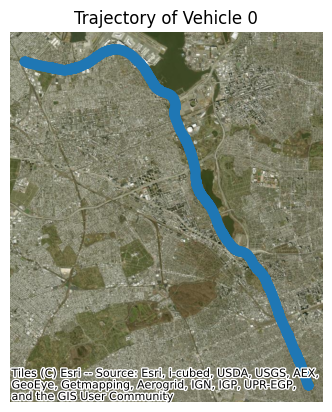

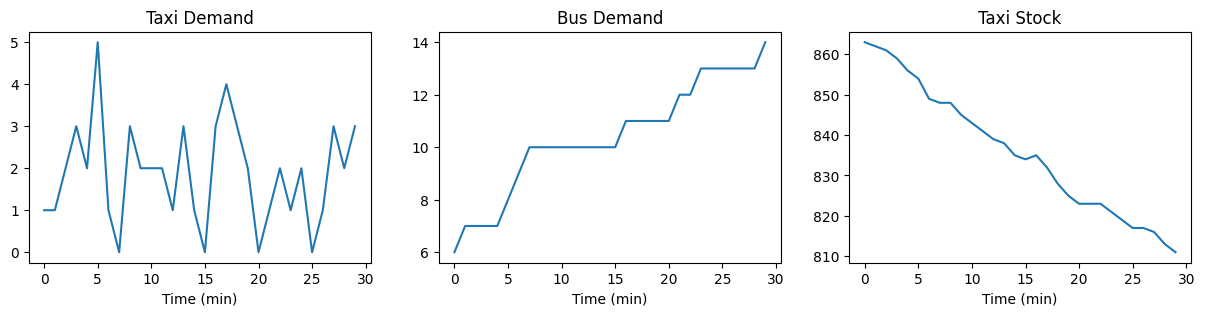

In [63]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()

# add the NYC map
gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(xs, ys), crs='EPSG:4326').to_crs(epsg=3857)
gdf.plot(ax = ax)
ax.set_title("Trajectory of Vehicle 0")
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)

ax.set_axis_off()

plt.show()

# Example 2: Minitor the state of a zone
fig, axs = plt.subplots(1,3, figsize=(15,3), sharex = True)

# The first two hours are 0-2:00, so the demand is low
axs[0].plot(taxi_demand)
axs[0].set_title("Taxi Demand")

axs[1].plot(bus_demand)
axs[1].set_title("Bus Demand")

axs[2].plot(taxi_stock)
axs[2].set_title("Taxi Stock")
for i in range(3):
      axs[i].set_xticks(range(0, 31, 5))
      axs[i].set_xticklabels(range(0, 31, 5))
      axs[i].set_xlabel("Time (min)")

plt.show()

Tear the simulator down before moving on to the next section.

In [64]:
sim_client.terminate()

# Section 3: Control APIs

Control calls let you inject, reroute, or override entities in the simulation. They always produce a response that tells you whether the command was accepted. We reuse the NYC scenario from Section 2.

## 3.1 Launch

In [65]:
from utils.util import *
from clients.METSRClient import METSRClient

In [66]:
config = read_run_config("configs/run_interactive_NYC.json")

In [67]:
sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)

No port number specified, find available ports for simulation instances
['output/NYC_20260601_001143_seed_42']


In [68]:
client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port=config.ports[0], timeout=300)

Connection established!


Start with an empty private-vehicle fleet &mdash; we'll populate it via control calls below.

In [69]:
# no private vehicle is in the simulation yet
client.query_vehicle(private_veh = True)['private_vids']

[]

## 3.2 Private vehicle trips

In [70]:
# generate a private vehicle trip
client.generate_trip(0, -1, -1)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'origin': 96, 'destination': 182, 'ID': 0}],
 'TYPE': 'CTRL_generateTrip'}

State `8` on a private vehicle means it is currently serving a trip.

In [71]:
# state 8 means the vehicle is performing a private trip
client.query_vehicle(0, private_veh = True)

{'DATA': [{'acc': 0.0,
   'bearing': 0.0,
   'x': -73.97844579462766,
   'y': 40.68792905862154,
   'z': 0.0,
   'ID': 6,
   'state': 8,
   'v_type': 3,
   'speed': 0.0}],
 'TYPE': 'ANS_vehicle'}

We can also dictate the O-D pair for the private trip.

In [72]:
# can also generate a private vehicle trip between two roads
import random
road_ids = client.query_road()
origin_road = random.choice(road_ids['orig_id'])
destination_road = random.choice(road_ids['orig_id'])

client.generate_trip_between_roads(1, origin_road, destination_road)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK',
   'origin': '-182690747#12',
   'destination': '961849758#3',
   'vehID': 1}],
 'TYPE': 'CTRL_genTripBwRoads'}

In [73]:
client.query_vehicle(1, private_veh = True)

{'DATA': [{'acc': 0.0,
   'bearing': 0.0,
   'x': -73.73973708430098,
   'y': 40.757648077964724,
   'z': 0.0,
   'ID': 8,
   'state': 8,
   'v_type': 3,
   'speed': 0.0}],
 'TYPE': 'ANS_vehicle'}

## 3.3 Taxi control

In [74]:
client.query_taxi(100)

{'DATA': [{'matchedPassengers': 0,
   'pass_num': 0,
   'matchedRequests': 0,
   'onBoardReqIDs': [],
   'origin': 132,
   'dropoffPassengers': 0,
   'dest': 132,
   'toBoardReqIDs': [],
   'pickupPassengers': 0,
   'x': -73.7872104492162,
   'dropoffRequests': 0,
   'y': 40.64671432368773,
   'z': 0.0,
   'pickupRequests': 0,
   'ID': 100,
   'state': 0}],
 'TYPE': 'ANS_taxi'}

`dispatch_taxi(vehID, reqID)` forces taxi 100 to pick up a passenger with ID reqID.

In [75]:
client.tick(300)

In [76]:
client.query_pending_requests()

{'CODE': 'OK',
 'DATA': [{'maxWaitingTime': 2520,
   'shareable': True,
   'currentWaitingTime': 300,
   'matchedTime': 0,
   'origin': 67,
   'destination': 181,
   'busRoute': -1,
   'numPeople': 1,
   'arriveTime': 0,
   'pickupTime': 0,
   'STATUS': 'OK',
   'destRoad': 66224,
   'generationTime': 300,
   'originRoad': 44677,
   'zoneID': 67,
   'ID': 9,
   'status': 'pending_taxi_sharable'},
  {'maxWaitingTime': 2520,
   'shareable': True,
   'currentWaitingTime': 300,
   'matchedTime': 0,
   'origin': 72,
   'destination': 181,
   'busRoute': -1,
   'numPeople': 1,
   'arriveTime': 0,
   'pickupTime': 0,
   'STATUS': 'OK',
   'destRoad': 66224,
   'generationTime': 300,
   'originRoad': 25495,
   'zoneID': 72,
   'ID': 10,
   'status': 'pending_taxi_sharable'},
  {'maxWaitingTime': 2520,
   'shareable': True,
   'currentWaitingTime': 600,
   'matchedTime': 0,
   'origin': 103,
   'destination': 181,
   'busRoute': -1,
   'numPeople': 1,
   'arriveTime': 0,
   'pickupTime': 0,
   

In [77]:
# generate a taxi trip with specific vehicles
client.dispatch_taxi(100, 12)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK',
   'origZone': 132,
   'ID': 100,
   'destZone': 200,
   'reqID': 12}],
 'TYPE': 'CTRL_dispatchTaxi'}

The taxi is now in state `6` (on a pickup leg); its reported destination is still the pickup zone.

In [78]:
# We see the veh's destination is still 140, this is because it is in a pickup trip (state 6)
client.query_taxi(100)

{'DATA': [{'matchedPassengers': 1,
   'pass_num': 1,
   'matchedRequests': 1,
   'onBoardReqIDs': [],
   'origin': 132,
   'dropoffPassengers': 0,
   'dest': 132,
   'toBoardReqIDs': [12],
   'pickupPassengers': 0,
   'x': -73.7872104492162,
   'dropoffRequests': 0,
   'y': 40.64671432368773,
   'z': 0.0,
   'pickupRequests': 0,
   'ID': 100,
   'state': 6}],
 'TYPE': 'ANS_taxi'}

In [79]:
# let's tick the simulation for 360s 
client.tick(1800)

After 6 minutes of simulated time, the taxi has completed the pickup and is now driving the passenger toward the drop-off.

In [80]:
# aha
client.query_taxi(100)

{'DATA': [{'matchedPassengers': 1,
   'pass_num': 1,
   'matchedRequests': 1,
   'onBoardReqIDs': [12],
   'origin': 132,
   'dropoffPassengers': 0,
   'dest': 200,
   'toBoardReqIDs': [],
   'pickupPassengers': 1,
   'x': -73.78914033037802,
   'dropoffRequests': 0,
   'y': 40.644898139384935,
   'z': 0.0,
   'pickupRequests': 1,
   'ID': 100,
   'state': 1}],
 'TYPE': 'ANS_taxi'}

### Taxi requests without a specific vehicle

`add_taxi_requests(origZone, destZone, numPassengers)` feeds a new request into the dispatcher, which will assign it to some available taxi at the next planning cycle (every 60 s in this scenario).

In [81]:
client.query_zone(140)

{'DATA': [{'veh_stock': 0,
   'matchedTaxiRequests': 0,
   'pickupBusPassengers': 0,
   'bus_demand': 0,
   'matchedBusRequests': 0,
   'dropoffBusPassengers': 0,
   'leftBusRequests': 0,
   'matchedBusPassengers': 0,
   'dropoffTaxiRequests': 0,
   'dropoffBusRequests': 0,
   'leftBusPassengers': 0,
   'pickupBusRequests': 0,
   'dropoffTaxiPassengers': 0,
   'taxi_demand': 0,
   'x': -73.9537822370563,
   'leftTaxiPassengers': 0,
   'y': 40.81797514762926,
   'pickupTaxiRequests': 0,
   'z': 0.0,
   'matchedTaxiPassengers': 0,
   'ID': 140,
   'leftTaxiRequests': 0,
   'pickupTaxiPassengers': 0,
   'z_type': 0}],
 'TYPE': 'ANS_zone'}

In [82]:
# generate a taxi request without specific vehicles
client.add_taxi_requests(140, 181, 3, 3000)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'ID': 140, 'reqID': 55}],
 'TYPE': 'CTRL_addTaxiRequests'}

In [83]:
# this will take effect when the next round of demand processing, which happens every 60s in this scenario
client.tick(600)

In [84]:
client.query_zone(140)

{'DATA': [{'veh_stock': 0,
   'matchedTaxiRequests': 0,
   'pickupBusPassengers': 0,
   'bus_demand': 0,
   'matchedBusRequests': 0,
   'dropoffBusPassengers': 0,
   'leftBusRequests': 0,
   'matchedBusPassengers': 0,
   'dropoffTaxiRequests': 0,
   'dropoffBusRequests': 0,
   'leftBusPassengers': 0,
   'pickupBusRequests': 0,
   'dropoffTaxiPassengers': 0,
   'taxi_demand': 1,
   'x': -73.9537822370563,
   'leftTaxiPassengers': 0,
   'y': 40.81797514762926,
   'pickupTaxiRequests': 0,
   'z': 0.0,
   'matchedTaxiPassengers': 0,
   'ID': 140,
   'leftTaxiRequests': 0,
   'pickupTaxiPassengers': 0,
   'z_type': 0}],
 'TYPE': 'ANS_zone'}

> Tip: `add_taxi_requests` also accepts road-level origin/destination IDs if you want pickup/drop-off to be deterministic rather than sampled inside the zone.

## 3.4 Bus schedules

Bus control follows the same pattern: first discover the vehicle, then send it an assignment.

In [85]:
buses = client.query_bus()['id_list']
buses

[4032,
 4033,
 4034,
 4035,
 4036,
 4037,
 4038,
 4039,
 4000,
 4001,
 4002,
 4003,
 4004,
 4005,
 4006,
 4007,
 4008,
 4009,
 4010,
 4011,
 4012,
 4013,
 4014,
 4015,
 4016,
 4017,
 4018,
 4019,
 4020,
 4021,
 4022,
 4023,
 4024,
 4025,
 4026,
 4027,
 4028,
 4029,
 4030,
 4031]

Tick forward until at least one bus has started its route (`route != -1`).

In [86]:
# Now, let's tick a little bit longer to let the bus operate
flag = True
while flag:
      client.tick(100)
      for bus in buses:
            if client.query_bus(bus)['DATA'][0]['route'] != -1:
                  print("Tick: ", client.current_tick)
                  print(bus)
                  flag = False
                  break
      if client.current_tick>=20000:
            break

Tick:  2800
4032


In [87]:
# Our target is this bus
client.query_bus(4032)

{'DATA': [{'matchedPassengers': 0,
   'battery_state': 233.4396471371927,
   'pickupPassengers': 0,
   'route': '1640002',
   'stopZones': [181, 157, 228, 176, 181],
   'current_stop': 0,
   'pass_num': 0,
   'matchedRequests': 0,
   'dropoffPassengers': 0,
   'dropoffRequests': 0,
   'pickupRequests': 0,
   'ID': 4032}],
 'TYPE': 'ANS_bus'}

In [88]:
client.query_bus_route('1640002')

{'DATA': [{'stopRoads': ['226041020#0',
    '458180188#0',
    '1189567313#8',
    '-43242499#23',
    '226041020#0'],
   'routeID': 26,
   'stopZones': [181, 157, 228, 176, 181],
   'routeName': '1640002'}],
 'TYPE': 'ANS_busRoute'}

In [89]:
client.add_bus_requests(157, 228, '1640002', 10, 3000)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'ID': 157, 'reqID': 69}],
 'TYPE': 'CTRL_addBusRequests'}

In [90]:
client.insert_bus_stop(4032, "1640002", 31, '1189567313#8', 3)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'ID': 4032}],
 'TYPE': 'CTRL_insertStopToRoute'}

In [91]:
client.query_bus(4032)

{'DATA': [{'matchedPassengers': 0,
   'battery_state': 233.4396471371927,
   'pickupPassengers': 0,
   'route': '1640002',
   'stopZones': [181, 157, 228, 31, 176, 181],
   'current_stop': 0,
   'pass_num': 0,
   'matchedRequests': 0,
   'dropoffPassengers': 0,
   'dropoffRequests': 0,
   'pickupRequests': 0,
   'ID': 4032}],
 'TYPE': 'ANS_bus'}

In [92]:
client.tick(1500)

In [93]:
# request already picked up
client.query_bus(4032)

{'DATA': [{'matchedPassengers': 10,
   'battery_state': 231.57743504592142,
   'pickupPassengers': 10,
   'route': '1640002',
   'stopZones': [181, 157, 228, 31, 176, 181],
   'current_stop': 1,
   'pass_num': 10,
   'matchedRequests': 1,
   'dropoffPassengers': 0,
   'dropoffRequests': 0,
   'pickupRequests': 1,
   'ID': 4032}],
 'TYPE': 'ANS_bus'}

## 3.5 Teleportation & acceleration override

These are primarily useful for scripted trace replays and adversarial scenarios. Teleportation must stay within the same road; the fourth parameter is the distance (m) from the target lane's downstream end.

In [94]:
# let's teleport the bus!
client.query_vehicle(4032, private_veh = False)

{'DATA': [{'acc': -0.5244750161357485,
   'road': '46522001#0',
   'bearing': 120.09034851727401,
   'x': -73.96810094163146,
   'y': 40.751431204771734,
   'dist': 3.4679114075141353,
   'z': 0.0,
   'ID': 4032,
   'state': 3,
   'v_type': 2,
   'speed': 1.9072665736143548,
   'lane': 0}],
 'TYPE': 'ANS_vehicle'}

In [95]:
# teleport a vehicle to a specific location (must within the same road), the fourth parameter is the target distance to the next intersection
client.teleport_trace_replay_vehicle(4032, roadID='46522003#0', laneID=0, dist=5.0, private_veh = False)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'ID': 4032}],
 'TYPE': 'CTRL_teleportTraceReplayVeh'}

In [96]:
# let's check the teleported vehicle
client.query_vehicle(4032, private_veh = False)

{'DATA': [{'acc': -0.5244750161357485,
   'road': '46522003#0',
   'bearing': 119.20038408877849,
   'x': -73.96868905873889,
   'y': 40.75493224553946,
   'dist': 5.0,
   'z': 0.0,
   'ID': 4032,
   'state': 3,
   'v_type': 2,
   'speed': 1.9072665736143548,
   'lane': 0}],
 'TYPE': 'ANS_vehicle'}

`control_vehicle(vehID, accel_m_s2)` forces the longitudinal acceleration for the next planning cycle.

In [97]:
# force the vehicle to take the specified acceleration
client.control_vehicle(4032, 2.0, private_veh = False)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'ID': 4032}],
 'TYPE': 'CTRL_controlVeh'}

## 3.6 Traffic signal control

The signal API exposes three levels of granularity: single-phase changes, phase-duration updates, and full phase plans (with sub-tick precision when you need it). The cell below demonstrates all of them on one intersection.

In [111]:
# First, let's query the signal to get its current state
signal_info = client.query_signal_between_roads('-1001065257', '119628652')
print("Current signal state:", signal_info)

signal_id = signal_info['DATA'][0]['signalID']
print(f"\nSignal ID: {signal_id}")
print(f"Current tick: {client.current_tick}\n")

Current signal state: {'DATA': [{'next_state': 1, 'upStreamRoad': '-1001065257', 'STATUS': 'OK', 'next_update_tick': 4740, 'downStreamRoad': '119628652', 'signalID': 322, 'junction_id': 2866, 'state': 0, 'phase_ticks': [400, 60, 300]}], 'TYPE': 'ANS_signalForConnection'}

Signal ID: 322
Current tick: 4340



In [112]:
# Example 1: Update signal phase (0=Green, 1=Yellow, 2=Red)
# Change the signal to green phase
result = client.update_signal(signal_id, targetPhase=0)
print("\n1. Updated signal to Green phase:")
print(result)

# Query again to see the updated state
updated_info = client.query_signal(signal_id)
print("\nSignal state after phase update:", updated_info)


1. Updated signal to Green phase:
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'next_update_tick': 4740, 'new_state': 0, 'ID': 322}], 'TYPE': 'CTRL_updateSignal'}

Signal state after phase update: {'DATA': [{'nex_state': 1, 'next_update_time': 4740, 'groupID': '1343521751_0', 'ID': 322, 'state': 0, 'phase_ticks': [400, 60, 300]}], 'TYPE': 'ANS_signal'}


In [113]:
# Example 2: Update signal timing (green, yellow, red durations in seconds)
# Set green=30s, yellow=5s, red=25s
result = client.update_signal_timing(signal_id, greenTime=30, yellowTime=5, redTime=25)
print("\n3. Updated signal timing (Green:30s, Yellow:5s, Red:25s):")
print(result)


3. Updated signal timing (Green:30s, Yellow:5s, Red:25s):
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'ID': 322, 'phase_ticks': [150, 25, 125]}], 'TYPE': 'CTRL_updateSignalTiming'}


In [114]:
# Example 3: Set a complete phase plan (timing + starting state + offset)
# This sets the entire phase plan: green=40s, yellow=6s, red=30s, start at green, with 5s offset
result = client.set_signal_phase_plan(signal_id, greenTime=40, yellowTime=6, redTime=30, 
                                        startPhase=0, phaseOffset=5)
print("\n4. Set complete phase plan (Green:40s, Yellow:6s, Red:30s, Start:Green, Offset:5s):")
print(result)


4. Set complete phase plan (Green:40s, Yellow:6s, Red:30s, Start:Green, Offset:5s):
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'next_update_tick': 4515, 'current_state': 0, 'ID': 322, 'phase_ticks': [200, 30, 150]}], 'TYPE': 'CTRL_setSignalPhasePlan'}


In [115]:
# Example 5: Set phase plan with tick-level precision (more precise control)
# Assuming 0.1s per tick: green=400 ticks (40s), yellow=60 ticks (6s), red=300 ticks (30s)
result = client.set_signal_phase_plan_ticks(signal_id, greenTicks=400, yellowTicks=60, 
                                                redTicks=300, startPhase=0, tickOffset=50)
print("\n5. Set phase plan with tick precision (Green:400 ticks, Yellow:60 ticks, Red:300 ticks):")
print(result)


5. Set phase plan with tick precision (Green:400 ticks, Yellow:60 ticks, Red:300 ticks):
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'next_update_tick': 4690, 'current_state': 0, 'ID': 322, 'phase_ticks': [400, 60, 300]}], 'TYPE': 'CTRL_setSignalPhasePlanTicks'}


In [116]:
client.terminate()

# Section 4: Real-time data stream

METS-R can publish a Kafka feed of per-tick Basic Safety Messages (BSMs) or travel time/energy consumption for a configurable subset of vehicles.

Running Kafka requires the auxiliary docker-compose stack under `docker/`. We switch back to the small CARLA Town05 map so this section is quick to run.

## 4.1 Launch Kafka and the simulator

In [117]:
from utils.util import *
from clients.METSRClient import METSRClient
from clients.KafkaDataProcessor import KafkaDataProcessor

In [118]:
config = read_run_config("configs/run_cosim_CARLAT5.json")

Bring Kafka + Zookeeper up, give them 10 s to finish starting, then prepare the simulation output folder and launch the simulator.

In [119]:
os.chdir("docker")
os.system("docker-compose up -d")
os.chdir("..")

time.sleep(10) # wait 10s for the Kafka servers to be up

sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)

['output/CARLAT05_20260601_003117_seed_42']


## 4.2 Connect client and data processor

In [120]:
sim_client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port=4000)

kafkaDataProcessor = KafkaDataProcessor(config)

Connection established!


## 4.3 Generate traffic and subscribe to V2X

Create 100 private-vehicle trips, then promote 10 of them to V2X vehicles so their BSMs start flowing into Kafka.

In [121]:
# First, generate 100 trips
sim_client.generate_trip(list(range(100)), -1, -1)


{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'origin': 14, 'destination': 19, 'ID': 0},
  {'STATUS': 'OK', 'origin': 7, 'destination': 18, 'ID': 1},
  {'STATUS': 'OK', 'origin': 4, 'destination': 15, 'ID': 2},
  {'STATUS': 'OK', 'origin': 13, 'destination': 20, 'ID': 3},
  {'STATUS': 'OK', 'origin': 2, 'destination': 2, 'ID': 4},
  {'STATUS': 'OK', 'origin': 8, 'destination': 15, 'ID': 5},
  {'STATUS': 'OK', 'origin': 13, 'destination': 18, 'ID': 6},
  {'STATUS': 'OK', 'origin': 9, 'destination': 6, 'ID': 7},
  {'STATUS': 'OK', 'origin': 13, 'destination': 1, 'ID': 8},
  {'STATUS': 'OK', 'origin': 15, 'destination': 3, 'ID': 9},
  {'STATUS': 'OK', 'origin': 16, 'destination': 22, 'ID': 10},
  {'STATUS': 'OK', 'origin': 4, 'destination': 4, 'ID': 11},
  {'STATUS': 'OK', 'origin': 18, 'destination': 2, 'ID': 12},
  {'STATUS': 'OK', 'origin': 14, 'destination': 2, 'ID': 13},
  {'STATUS': 'OK', 'origin': 12, 'destination': 9, 'ID': 14},
  {'STATUS': 'OK', 'origin': 14, 'destination': 2, 'ID':

In [122]:
# Set up 10 vehicles as V2X vehicles
sim_client.update_vehicle_sensor_type(list(range(10, 20)), 1, True)

{'CODE': 'OK',
 'DATA': [{'STATUS': 'OK', 'ID': 10},
  {'STATUS': 'OK', 'ID': 11},
  {'STATUS': 'OK', 'ID': 12},
  {'STATUS': 'OK', 'ID': 13},
  {'STATUS': 'OK', 'ID': 14},
  {'STATUS': 'OK', 'ID': 15},
  {'STATUS': 'OK', 'ID': 16},
  {'STATUS': 'OK', 'ID': 17},
  {'STATUS': 'OK', 'ID': 18},
  {'STATUS': 'OK', 'ID': 19}],
 'TYPE': 'CTRL_updateVehicleSensorType'}

Every iteration advances the sim by 1 s and drains whatever messages arrived during that window.

In [123]:
# consume the information from the data stream every 1s
for i in range(100):
      sim_client.tick(10)
      res = kafkaDataProcessor.process()
      if res is not None:
            break
      print(res)

None
None
None
None
None
None
None


Inspect a single BSM.

In [124]:
res

[{'qty_SV_in_view': 9,
  'quality_layer': {'payload_bytes': 96,
   'estimated_end_to_end_latency_ms': 2.904,
   'confidence': 0.356,
   'simulation_only': True},
  'altitude': 0.0,
  'elevation_confidence': 5.333333333333333,
  'leap_seconds': 18,
  'latitude': 0.0007736114783841517,
  'type': 1,
  'communication_layer': {'stack': 'DSRC/WAVE',
   'message_family': 'SAE_J2735_BSM',
   'standards': ['IEEE 802.11p PHY/MAC', 'IEEE 1609.4 multi-channel'],
   'channel': {'multi_channel_operation': True,
    'control_channel': 178,
    'service_channel': 172,
    'channel_role': 'safety_bsm',
    'sync_interval_ms': 100,
    'channel_interval_ms': 50,
    'psid': '0x20'},
   'phy': {'radio_access': 'C_V2X_MODELED_WITH_WAVE_ENVELOPE',
    'carrier_frequency_mhz': 5860.0,
    'bandwidth_mhz': 10.0,
    'data_rate_mbps': 6.0,
    'tx_power_dbm': 20.0,
    'antenna_gain_dbi': 3.0,
    'range_m': 300.0,
    'thermal_noise_dbm': -95.0,
    'interference_dbm': -88.765,
    'rx_power_dbm_at_range': -

## 4.4 Tear down

In [125]:
sim_client.terminate()

In [126]:
os.chdir("docker")
os.system("docker-compose down")
os.chdir("..")